In [1]:
import os
import sys
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


if not os.path.exists('/kaggle/working/Transferable_RA'):
    !git clone https://github.com/liuzhuang13/Transferable_RA.git /kaggle/working/Transferable_RA
sys.path.append('/kaggle/working/Transferable_RA')


class EncoderRA_Attention(nn.Module):
    def __init__(self, ra_model):
        super(EncoderRA_Attention, self).__init__()
        self.ra_model = ra_model
        for param in self.ra_model.parameters():
            param.requires_grad = False
        self.adaptive_pool = nn.AdaptiveAvgPool2d((14, 14))

    def forward(self, images):
        with torch.no_grad(): 
            b1 = self.ra_model.block1(images)
            b2 = self.ra_model.block2(b1)
            b3 = self.ra_model.block3(b2)
            b4 = self.ra_model.block4(b3)
            b5 = self.ra_model.block5(b4)
            b6 = self.ra_model.block6(b5)
            b7 = self.ra_model.block7(b6)
            features = b1 + b7 
        features = self.adaptive_pool(features)
        batch_size = features.size(0)
        channels = features.size(1)
        features = features.view(batch_size, channels, -1).permute(0, 2, 1) 
        return features

class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)  
        self.decoder_att = nn.Linear(decoder_dim, attention_dim) 
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out) 
        att2 = self.decoder_att(decoder_hidden).unsqueeze(1) 
        att = self.full_att(self.relu(att1 + att2)).squeeze(2) 
        alpha = self.softmax(att) 
        attention_weighted_encoding = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return attention_weighted_encoding, alpha

class DecoderRNN_Attention(nn.Module):
    def __init__(self, vocab_size, embed_dim, decoder_dim, attention_dim, encoder_dim=64):
        super(DecoderRNN_Attention, self).__init__()
        self.vocab_size = vocab_size
        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm_cell = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)

    def forward(self, features, captions):
        pass 

#LOAD MODELS
print("Loading Model (The Eyes)")
weights_path = '/kaggle/input/datasets/siddharthreddy1809/ra-model-weights/model_dn_ra_r18.pth' 
author_model = torch.load(weights_path, map_location=device, weights_only=False)
if hasattr(author_model, 'module'): 
    author_model = author_model.module
author_model = author_model.to(device)

print("Building Architecture")

encoder = EncoderRA_Attention(author_model).to(device)
decoder = DecoderRNN_Attention(vocab_size=7737, embed_dim=256, decoder_dim=512, attention_dim=256).to(device)


CHECKPOINT_PATH = '/kaggle/input/datasets/siddharthreddy1809/epoch-20/attention_model_epoch_20.pth'

print("Loading Brain")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
decoder.load_state_dict(checkpoint['decoder_state_dict'])

encoder.eval()
decoder.eval()
print("loaded")

Cloning into '/kaggle/working/Transferable_RA'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 24 (delta 6), reused 10 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 745.53 KiB | 13.31 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Loading Model (The Eyes)
Building Architecture


/usr/local/lib/python3.12/dist-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.parallel.data_parallel.DataParallel' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/usr/local/lib/python3.12/dist-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.container.Sequential' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/usr/local/lib/python3.12/dist-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.conv.Conv2d' has changed. you can retrieve the original source code by accessing the object's source

Loading Brain
loaded


building Vocabulary.
Dictionary Size: 7737 words.

Processing Image


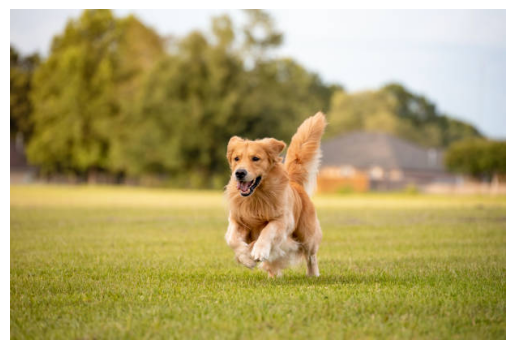

caption: a dog runs through the grass .

Processing Image


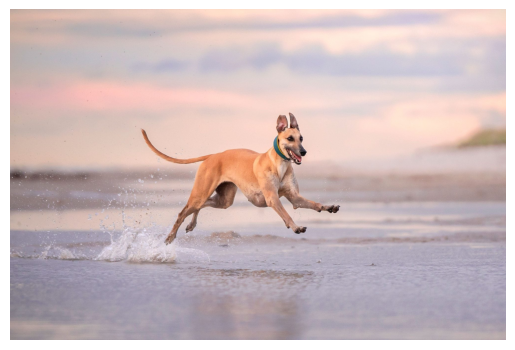

caption: a dog is running on the beach .

Processing Image


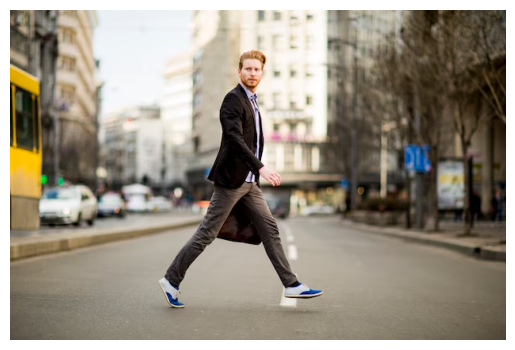

caption: a man in a blue shirt is walking down the street .

Processing Image


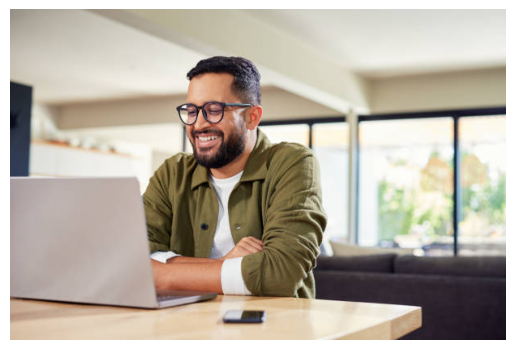

caption: a man in a black shirt and jeans is standing in front of a desk with a laptop computer in

Processing Image


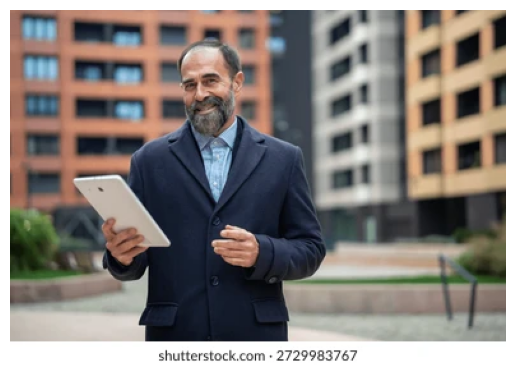

caption: a man in a black shirt is holding a baby .


In [19]:
import glob
import pandas as pd
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt


import glob
import pandas as pd

print("building Vocabulary.")
csv_files = glob.glob('/kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/results.csv', recursive=True)
CSV_FILE = csv_files[0]

class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<START>", 2: "<END>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<START>": 1, "<END>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def tokenize(self, text):
        return str(text).lower().split()

    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] = frequencies.get(word, 0) + 1
                
              
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

df = pd.read_csv(CSV_FILE, delimiter='|', skipinitialspace=True, on_bad_lines='skip')
df.columns = df.columns.str.strip()
df = df.dropna(subset=['comment'])

captions = df['comment'].astype(str).tolist()

vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(captions)

print(f"Dictionary Size: {len(vocab.itos)} words.")

#TEST FUNCTION

def test_random_image(image_path, encoder, decoder, vocab, max_length=20):
    
    
    transform = T.Compose([
        T.Resize((256, 256)),
        T.ToTensor()
    ])
    
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        features = encoder(img_tensor)
        sentence = ["<START>"]
        
        mean_features = features.mean(dim=1)
        h = decoder.init_h(mean_features)
        c = decoder.init_c(mean_features)
        
        for _ in range(max_length):
            last_word_idx = torch.tensor([vocab.stoi.get(sentence[-1], vocab.stoi["<UNK>"])]).to(device)
            embed = decoder.embedding(last_word_idx)
            
            context, _ = decoder.attention(features, h)
            lstm_input = torch.cat([embed, context], dim=1)
            h, c = decoder.lstm_cell(lstm_input, (h, c))
            
            output = decoder.fc(h)
            predicted_idx = output.argmax(1).item()
            word = vocab.itos.get(predicted_idx, "<UNK>")
            
            if word == "<END>":
                break
                
            sentence.append(word)
            
   
    import matplotlib.pyplot as plt
    plt.imshow(img)
    plt.axis('off')
    plt.show()
            
    return " ".join(sentence[1:])

#Testing picture

TEST_IMAGE_PATH = "/kaggle/input/datasets/siddharthreddy1809/test-11/test 12.jpg" 

print(f"\nProcessing Image")
caption = test_random_image(TEST_IMAGE_PATH, encoder, decoder, vocab)


print(f"caption: {caption}")



#Testing picture

TEST_IMAGE_PATH = "/kaggle/input/datasets/siddharthreddy1809/test-12/test 13.jpg" 

print(f"\nProcessing Image")
caption = test_random_image(TEST_IMAGE_PATH, encoder, decoder, vocab)


print(f"caption: {caption}")

#Testing picture

TEST_IMAGE_PATH = "/kaggle/input/datasets/siddharthreddy1809/test-11/test 10.avif" 

print(f"\nProcessing Image")
caption = test_random_image(TEST_IMAGE_PATH, encoder, decoder, vocab)


print(f"caption: {caption}")



#Testing picture

TEST_IMAGE_PATH = "/kaggle/input/datasets/siddharthreddy1809/test-6/test5.jpg" 

print(f"\nProcessing Image")
caption = test_random_image(TEST_IMAGE_PATH, encoder, decoder, vocab)


print(f"caption: {caption}")

#Testing picture

TEST_IMAGE_PATH = "/kaggle/input/datasets/siddharthreddy1809/test-8/test 9.webp" 

print(f"\nProcessing Image")
caption = test_random_image(TEST_IMAGE_PATH, encoder, decoder, vocab)


print(f"caption: {caption}")


In [ ]:
#epoch 15 test is below


Processing Image...


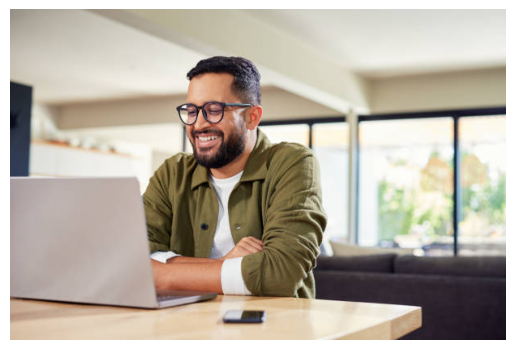


Caption: a man in a blue shirt is sitting on a bench .



In [14]:
TEST_IMAGE_PATH = "/kaggle/input/datasets/siddharthreddy1809/test-6/test5.jpg" 

print(f"\nProcessing Image...")
caption = test_random_image(TEST_IMAGE_PATH, encoder, decoder, vocab)

print(f"\n========================================")
print(f"Caption: {caption}")
print(f"========================================\n")

In [ ]:
#epoch 5 testing


Processing Image...


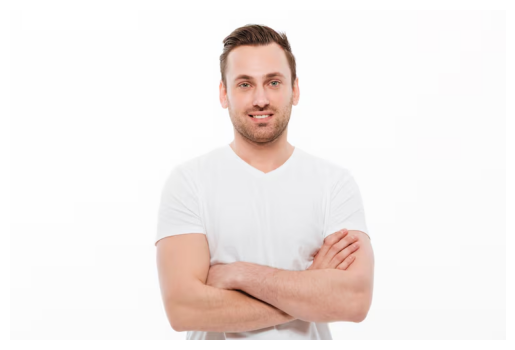


Caption: a man is standing on a snowy mountain .



In [13]:
TEST_IMAGE_PATH = "/kaggle/input/datasets/siddharthreddy1809/testimgs1/test3.avif" 

print(f"\nProcessing Image...")
caption = test_random_image(TEST_IMAGE_PATH, encoder, decoder, vocab)

print(f"\n========================================")
print(f"Caption: {caption}")
print(f"========================================\n")

Extracting Attention Maps...
Caption: a man is standing on a snowy mountain .



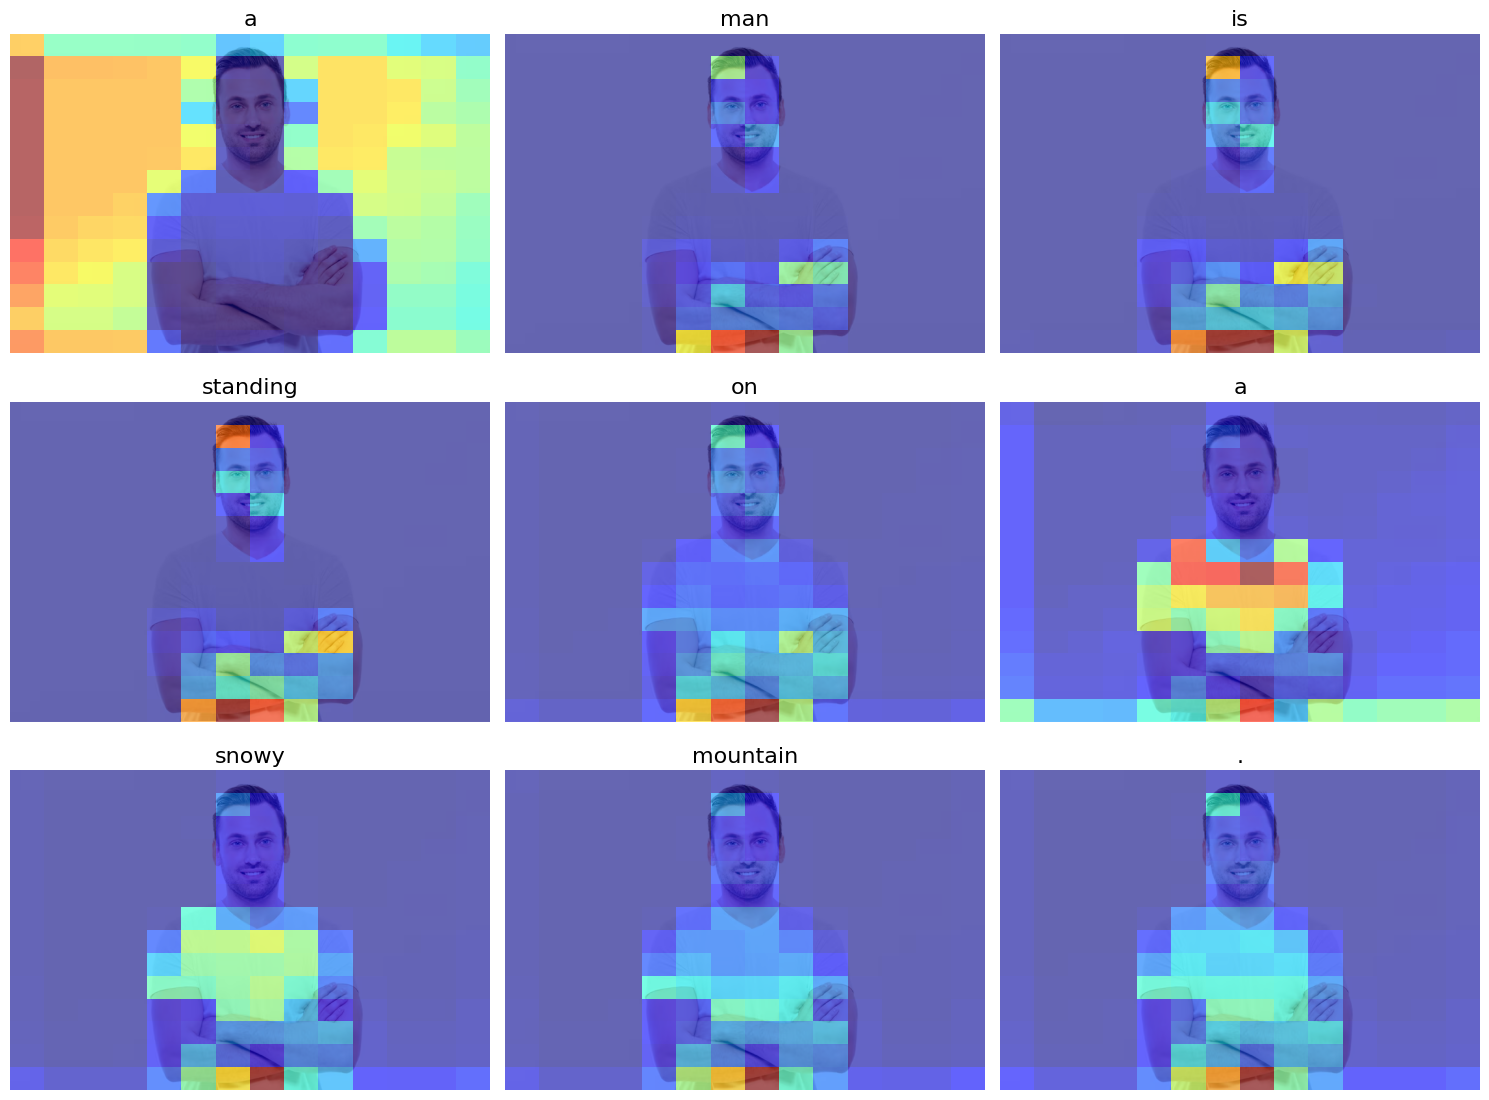

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torchvision.transforms as T

def get_caption_and_attention(image_path, encoder, decoder, vocab, max_length=20):
    transform = T.Compose([T.Resize((256, 256)), T.ToTensor()])
    
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    alphas = []
    sentence = ["<START>"]
    
    with torch.no_grad():
        features = encoder(img_tensor)
        mean_features = features.mean(dim=1)
        h = decoder.init_h(mean_features)
        c = decoder.init_c(mean_features)
        
        for _ in range(max_length):
            last_word_idx = torch.tensor([vocab.stoi.get(sentence[-1], vocab.stoi["<UNK>"])]).to(device)
            embed = decoder.embedding(last_word_idx)
            
            context, alpha = decoder.attention(features, h)
            
            # Save the attention map for this word!
            alphas.append(alpha.cpu().detach().numpy())
            
            lstm_input = torch.cat([embed, context], dim=1)
            h, c = decoder.lstm_cell(lstm_input, (h, c))
            
            output = decoder.fc(h)
            predicted_idx = output.argmax(1).item()
            word = vocab.itos.get(predicted_idx, "<UNK>")
            
            if word == "<END>":
                break
            sentence.append(word)
            
    return img, sentence[1:], alphas

def plot_attention(img, result, alphas):
    fig = plt.figure(figsize=(15, 15))
    len_result = len(result)
    
    for l in range(len_result):
        # Resize the 14x14 attention map back to the image size
        attention_map = np.resize(alphas[l], (14, 14))
        
        ax = fig.add_subplot(len_result // 3 + 1, 3, l + 1)
        ax.set_title(result[l], fontsize=16)
        
        # Show the image
        ax.imshow(img)
        # Overlay the attention heatmap (alpha=0.6 makes it semi-transparent)
        ax.imshow(attention_map, cmap='jet', alpha=0.6, extent=(0, img.size[0], img.size[1], 0))
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# --- RUN THE VISUALIZER ---
TEST_IMAGE_PATH = "/kaggle/input/datasets/siddharthreddy1809/testimgs1/test3.avif" # ⚠️ Update this!
print("Extracting Attention Maps...")
img, caption_words, attention_scores = get_caption_and_attention(TEST_IMAGE_PATH, encoder, decoder, vocab)

print(f"Caption: {' '.join(caption_words)}\n")
plot_attention(img, caption_words, attention_scores)

In [12]:
# --- Run this specifically for the laptop man image ---
# Update this path to where your laptop man image is stored in Kaggle
LAPTOP_MAN_PATH = "/kaggle/input/datasets/siddharthreddy1809/test-6/test5.jpg" 

print("🔍 Analyzing Epoch 15 Attention for 'Cigarette' and 'Glass'...")
img, result, alphas = get_caption_and_attention(LAPTOP_MAN_PATH, encoder, decoder, vocab)

print(f"🤖 MODEL SAYS: {' '.join(result)}\n")
plot_attention(img, result, alphas)

🔍 Analyzing Epoch 15 Attention for 'Cigarette' and 'Glass'...


NameError: name 'get_caption_and_attention' is not defined